In [6]:
import pandas as pd
df = pd.read_csv(r"./simulation_results.csv")
print(df)

         Seed  Spawn_Strategy  \
0      965496               1   
1      965496               2   
2      965496               4   
3      965496               8   
4      965496              16   
...       ...             ...   
22183  905893               2   
22184  905893               4   
22185  905893               8   
22186  905893              16   
22187  905893              32   

                                       Initial_Drones_XY  Goal_X  Goal_Y  \
0                                             [(31, 31)]      53      49   
1                                   [(15, 31), (47, 31)]      53      49   
2               [(15, 15), (15, 47), (47, 15), (47, 47)]      53      49   
3      [(7, 15), (7, 47), (23, 15), (23, 47), (39, 15...      53      49   
4      [(7, 7), (7, 23), (7, 39), (7, 55), (23, 7), (...      53      49   
...                                                  ...     ...     ...   
22183                               [(15, 31), (47, 31)]      29      2

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast

def plot_drone_spawn_heatmap(df: pd.DataFrame, n: int = 32):
    """
    pandas DataFrame을 입력받아 드론 초기 스폰 위치의 히트맵을 그리는 함수입니다.
    """
    # 1. n x n 크기의 빈 2차원 배열(0으로 채워짐) 생성
    heatmap_data = np.zeros((n, n), dtype=int)
    
    # 2. 드론 초기 좌표(Initial_Drones_XY) 카운트 누적
    for _, row in df.iterrows():
        # 문자열로 저장된 리스트 "[(x, y), ...]"를 실제 파이썬 리스트 객체로 변환
        drones_xy_list = ast.literal_eval(row['Initial_Drones_XY'])
        
        for x, y in drones_xy_list:
            # 미로 실제 좌표(1, 3, 5...)를 배열 인덱스(0, 1, 2...)로 변환
            grid_x = x
            grid_y = y
            heatmap_data[grid_x, grid_y] += 1

    # 3. 데이터 시각화 (히트맵)
    plt.figure(figsize=(10, 8))
    
    # 한글 폰트 설정 (윈도우: Malgun Gothic / 맥: AppleGothic)
    plt.rcParams['font.family'] = 'Malgun Gothic' 
    plt.rcParams['axes.unicode_minus'] = False
    
    # 드론 느낌이 나도록 파란색 톤(Blues)으로 설정
    sns.heatmap(heatmap_data, cmap="Blues", annot=False, cbar=True, square=True)
    
    plt.title(f"드론 초기 스폰(Spawn) 위치 누적 분포도 (n={n})", fontsize=15, pad=15)
    plt.xlabel("Y 좌표 (인덱스)", fontsize=12)
    plt.ylabel("X 좌표 (인덱스)", fontsize=12)
    plt.show()
    
    return heatmap_data



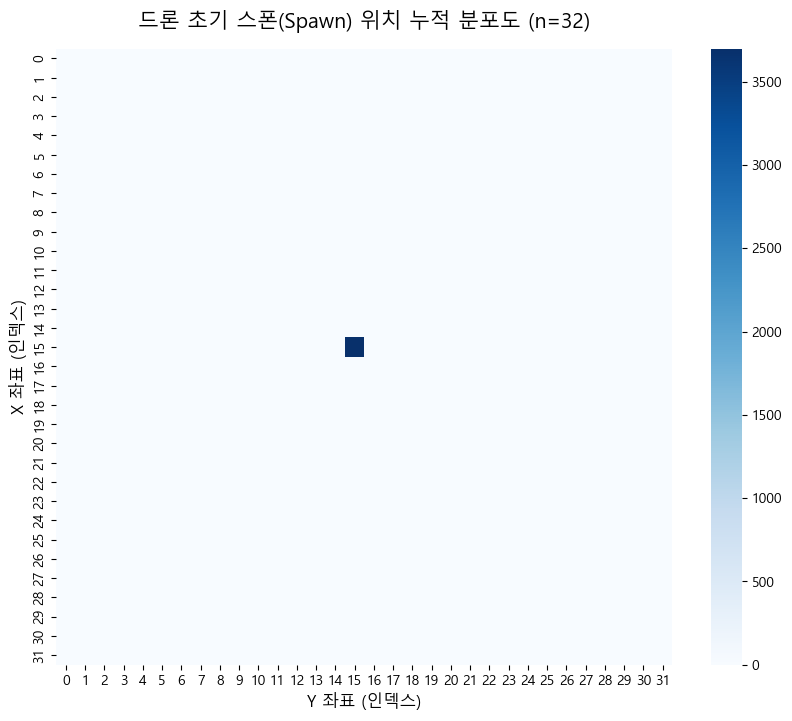

In [8]:
heatmap_matrix = plot_drone_spawn_heatmap(df[df["Spawn_Strategy"] == 1])
#heatmap_matrix = plot_drone_spawn_heatmap(df[df["Spawn_Strategy"] == 32].iloc[[10]])

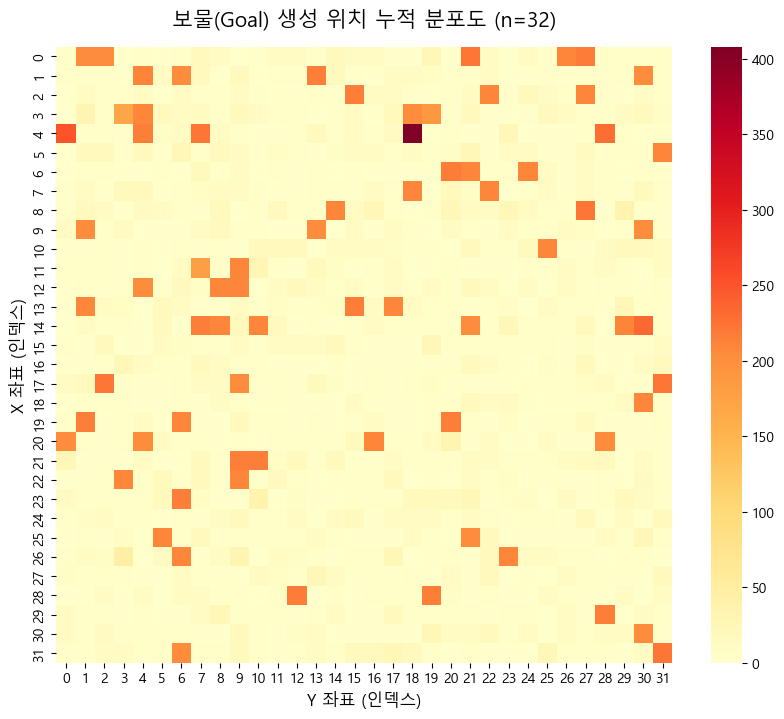

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_goal_heatmap(df: pd.DataFrame, n: int = 32):
    """
    pandas DataFrame을 입력받아 보물(Goal) 생성 위치의 히트맵을 그리는 함수입니다.
    """
    # 1. n x n 크기의 빈 2차원 배열(0으로 채워짐) 생성
    heatmap_data = np.zeros((n, n), dtype=int)
    
    # 2. 보물 좌표(Goal_X, Goal_Y) 카운트 누적
    for _, row in df.iterrows():
        # 데이터프레임에서 직접 X, Y 좌표 추출
        x = row['Goal_X']
        y = row['Goal_Y']
        
        # 미로 실제 좌표(1, 3, 5...)를 배열 인덱스(0, 1, 2...)로 변환
        grid_x = x
        grid_y = y
        
        heatmap_data[grid_x, grid_y] += 1

    # 3. 데이터 시각화 (히트맵)
    plt.figure(figsize=(10, 8))
    
    # 한글 폰트 설정 (윈도우: Malgun Gothic / 맥: AppleGothic)
    plt.rcParams['font.family'] = 'Malgun Gothic' 
    plt.rcParams['axes.unicode_minus'] = False
    
    # 보물 느낌이 나도록 붉은색/노란색 톤(YlOrRd)으로 설정
    sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, cbar=True, square=True)
    
    plt.title(f"보물(Goal) 생성 위치 누적 분포도 (n={n})", fontsize=15, pad=15)
    plt.xlabel("Y 좌표 (인덱스)", fontsize=12)
    plt.ylabel("X 좌표 (인덱스)", fontsize=12)
    plt.show()
    
    return heatmap_data

# ==========================================
# [사용 예시]
# df = pd.read_csv("./simulation_results.csv")
goal_heatmap_matrix = plot_goal_heatmap(df)

In [12]:
print(*df.columns, sep="\n")

Seed
Spawn_Strategy
Initial_Drones_XY
Goal_X
Goal_Y
Optimal_Tick
Used_Tick
Map_Coverage_%
Spawn_Fail_Count
Backtrack_Count
Total_Spawned
Success


In [14]:
print(df[df["Spawn_Strategy"] == "16"])

Empty DataFrame
Columns: [Seed, Spawn_Strategy, Initial_Drones_XY, Goal_X, Goal_Y, Optimal_Tick, Used_Tick, Map_Coverage_%, Spawn_Fail_Count, Backtrack_Count, Total_Spawned, Success]
Index: []


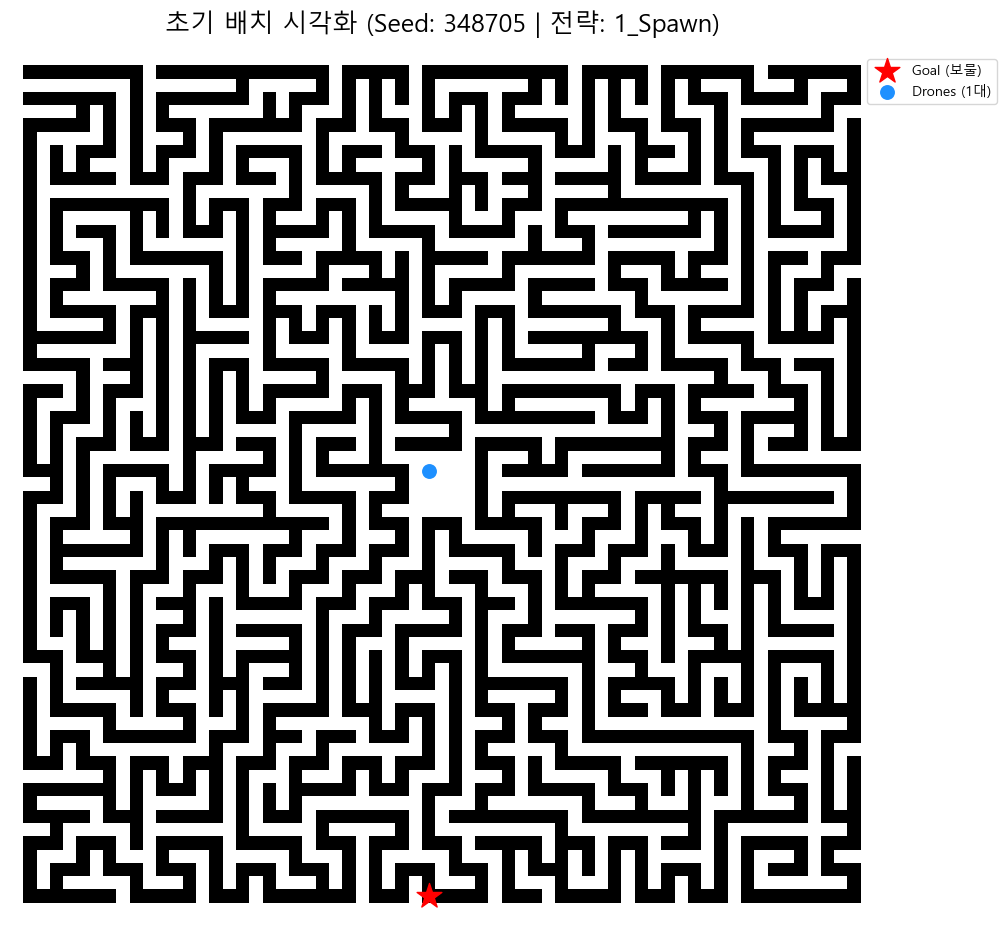

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
from maze import Maze  # 우리가 만든 maze.py의 Maze 클래스를 불러옵니다.

def draw_maze_setup(seed_value, drone_count, n=32):
    """
    특정 시드와 드론 개수를 입력받아 초기 미로 배치 상태를 시각화합니다.
    """
    # 1. 시드 고정 및 맵 생성 (이때 최신 maze.py의 구역 분할 로직이 작동함)
    random.seed(seed_value)
    maze_env = Maze(n=n, num_initial_drones=drone_count)
    
    maze_data = np.array(maze_env.maze)
    d_locations = maze_env.d_locations
    gx, gy = maze_env.g_location

    # 2. 시각화 캔버스 설정
    plt.figure(figsize=(10, 10))
    
    # 한글 폰트 설정
    plt.rcParams['font.family'] = 'Malgun Gothic' # 맥은 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    # 3. 미로 지형 그리기 (벽=0(검정), 길=1(흰색))
    # cmap='binary'를 사용하여 0은 흑, 1은 백으로 렌더링
    plt.imshow(maze_data, cmap='binary')
    
    # 4. 목적지(Goal) 그리기 (빨간색 별)
    # 2차원 배열(행렬) 인덱스와 그래프의 x, y 축 방향을 맞추기 위해 x, y 위치를 교차해서 넣습니다.
    plt.scatter(gy, gx, c='red', marker='*', s=350, label='Goal (보물)', zorder=5)
    
    # 5. 드론 초기 위치 그리기 (파란색 동그라미)
    if d_locations:
        # [(r1, c1), (r2, c2) ...] 형태를 y, x 좌표 리스트로 분리
        dy, dx = zip(*d_locations) 
        plt.scatter(dx, dy, c='dodgerblue', marker='o', s=150, 
                    edgecolors='white', linewidths=1.5, 
                    label=f'Drones ({drone_count}대)', zorder=5)

    # 6. 제목 및 범례 설정
    plt.title(f"초기 배치 시각화 (Seed: {seed_value} | 전략: {drone_count}_Spawn)", fontsize=18, pad=15)
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    
    # 축 눈금(인덱스)을 보고 싶다면 아래 줄을 주석 처리하세요.
    plt.axis('off') 
    
    plt.tight_layout()
    plt.show()

# ==========================================
# [실행 예시]
# CSV에서 흥미로운 결과를 보인 Seed값과 확인하고 싶은 드론 수를 입력하세요.
# ==========================================
target_seed = 348705  # 예시 시드 번호
target_drones = 1    # 1, 2, 4, 8, 16, 32 등

draw_maze_setup(seed_value=target_seed, drone_count=target_drones)